Dataset successfully loaded. Shape: (236268, 35)


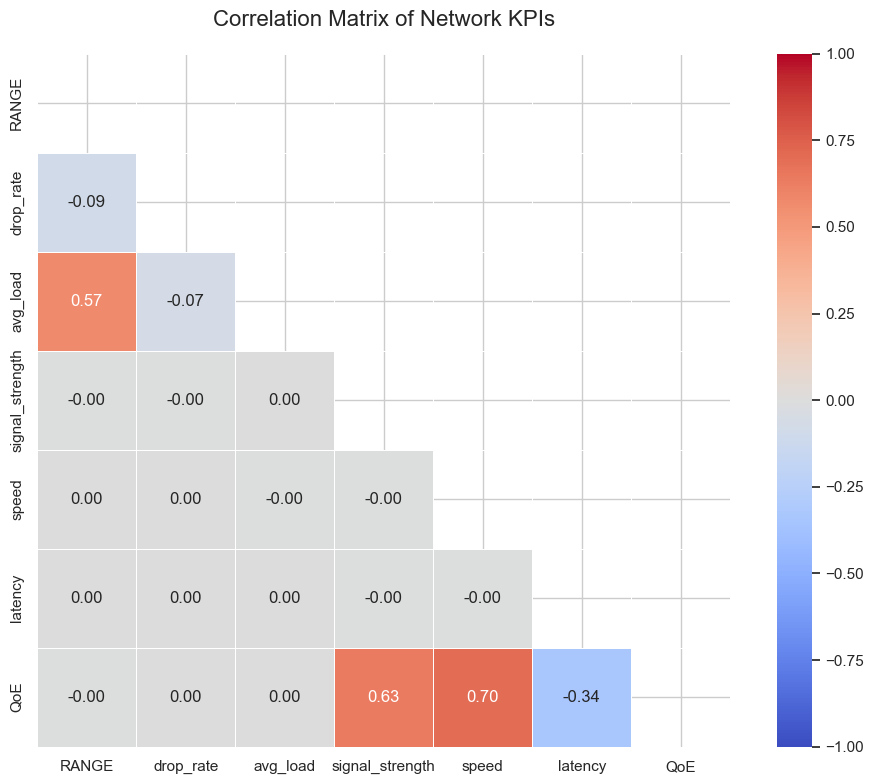

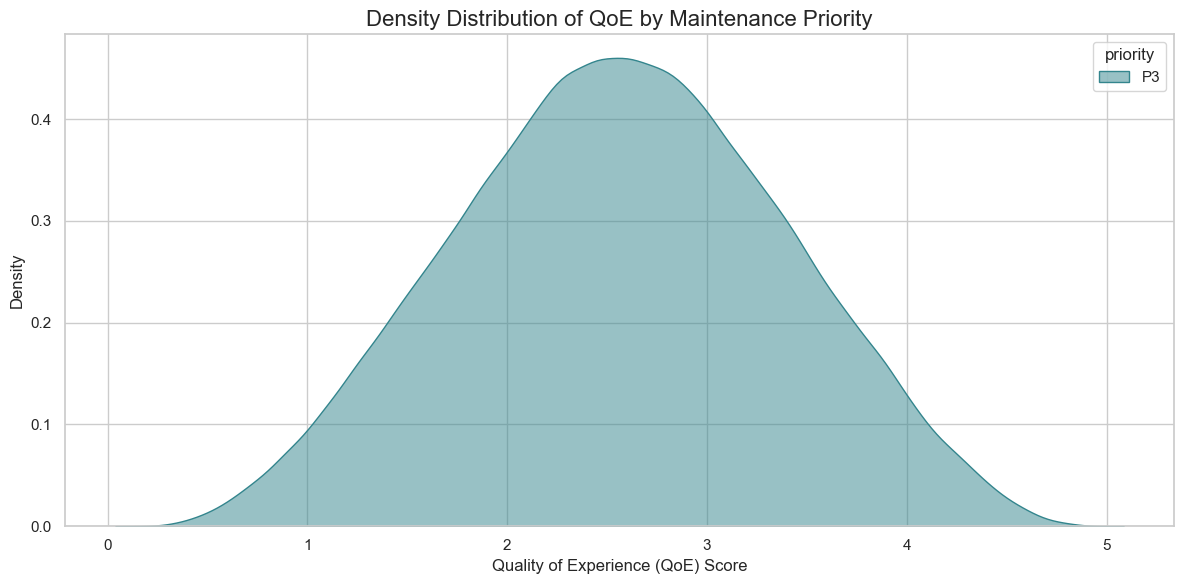

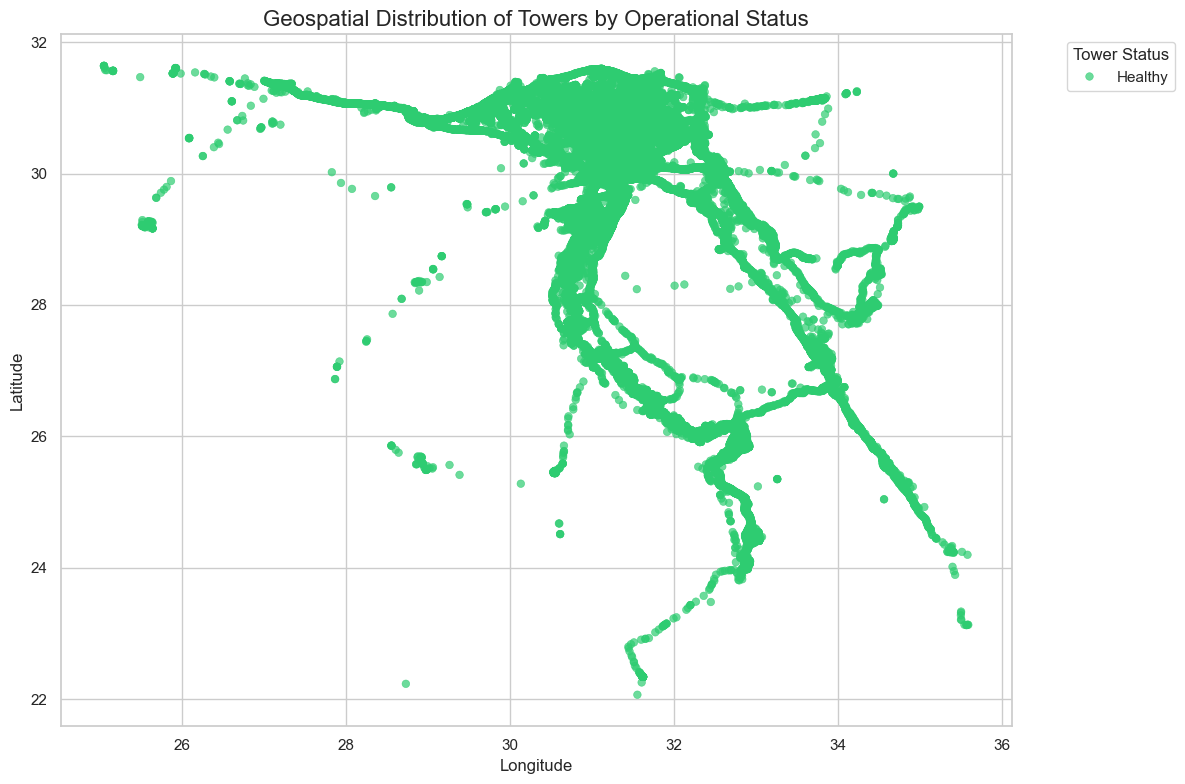

C:\Users\ahme\AppData\Local\Temp\ipykernel_21768\853346547.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='maintenance_type', y='labor_cost_egp', ax=axes[0], palette='Set2')
C:\Users\ahme\AppData\Local\Temp\ipykernel_21768\853346547.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='maintenance_type', y='parts_cost_egp', ax=axes[1], palette='Set3')


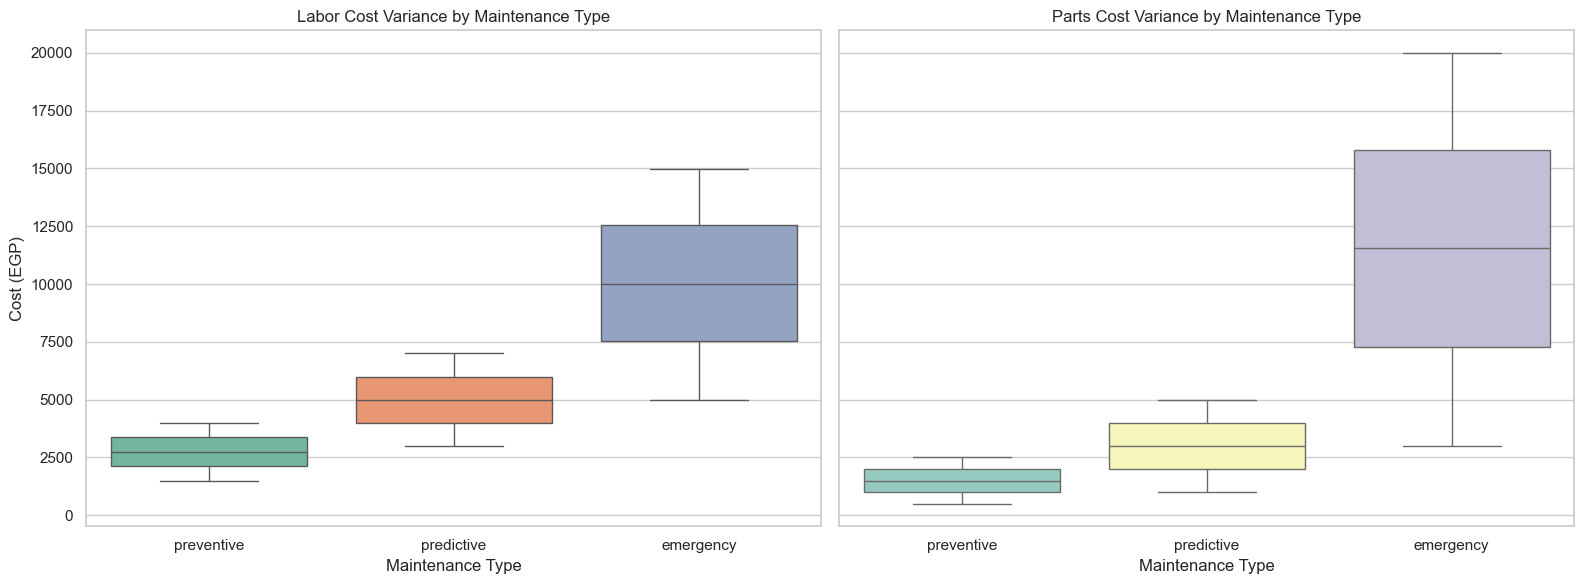

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic parameters for professional-grade plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.max_open_warning': 0, 'font.size': 12})

# Load the processed dataset we generated earlier
df = pd.read_csv('data/FULL_telecom_dataset.csv')
print(f"Dataset successfully loaded. Shape: {df.shape}")

# 1. Correlation Matrix
plt.figure(figsize=(10, 8))
continuous_vars = ['RANGE', 'drop_rate', 'avg_load', 'signal_strength', 'speed', 'latency', 'QoE']
corr_matrix = df[continuous_vars].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmax=1, vmin=-1, center=0, square=True, linewidths=.5)
plt.title('Correlation Matrix of Network KPIs', pad=20, fontsize=16)
plt.tight_layout()
plt.show()

# 2. Density Distribution of QoE
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='QoE', hue='priority', fill=True, common_norm=False, palette='crest', alpha=0.5)
plt.title('Density Distribution of QoE by Maintenance Priority', fontsize=16)
plt.xlabel('Quality of Experience (QoE) Score')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

# 3. Geospatial Distribution
plt.figure(figsize=(12, 8))
status_colors = {'Healthy': '#2ecc71', 'Warning': '#f1c40f', 'Critical': '#e67e22', 'Failed': '#e74c3c'}
sns.scatterplot(data=df, x='LON', y='LAT', hue='tower_status', palette=status_colors, s=30, alpha=0.7, edgecolor=None)
plt.title('Geospatial Distribution of Towers by Operational Status', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Tower Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 4. Maintenance Costs Boxplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
sns.boxplot(data=df, x='maintenance_type', y='labor_cost_egp', ax=axes[0], palette='Set2')
axes[0].set_title('Labor Cost Variance by Maintenance Type')
axes[0].set_ylabel('Cost (EGP)')
axes[0].set_xlabel('Maintenance Type')
sns.boxplot(data=df, x='maintenance_type', y='parts_cost_egp', ax=axes[1], palette='Set3')
axes[1].set_title('Parts Cost Variance by Maintenance Type')
axes[1].set_ylabel('')
axes[1].set_xlabel('Maintenance Type')
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd

# 0. Load the dataset first so Python knows what 'df' is!
df = pd.read_csv('data/FULL_telecom_dataset.csv')

# --- Data Quality Validation Checks ---
print("--- Data Quality Report ---")

# 1. Check dataset size
print(f"Total Rows: {len(df):,}")
print(f"Total Columns: {len(df.columns)}")

# 2. Check for Missing Values (Nulls)
missing_values = df.isnull().sum().sum()
print(f"\nTotal Missing Values: {missing_values} -> (Should be 0)")

# 3. Check for Duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates} -> (Should be 0)")

# 4. Check if the geographic filter worked
countries = df['Country'].unique()
print(f"\nCountries in dataset: {countries} -> (Should only be ['Egypt'])")

# 5. Check if unnecessary columns were dropped
dropped_cols = ['unit', 'changeable', 'averageSignal', 'Continent']
still_exist = [col for col in dropped_cols if col in df.columns]
print(f"Dropped columns still present: {still_exist} -> (Should be an empty list [])")

# 6. Sanity check the math (Drop rate must be a percentage between 0 and 100)
invalid_drop_rates = df[~df['drop_rate'].between(0, 100)]
print(f"\nRows with invalid drop rates: {len(invalid_drop_rates)} -> (Should be 0)")

--- Data Quality Report ---
Total Rows: 236,268
Total Columns: 35

Total Missing Values: 118148 -> (Should be 0)
Duplicate Rows: 0 -> (Should be 0)

Countries in dataset: <StringArray>
['Egypt']
Length: 1, dtype: str -> (Should only be ['Egypt'])
Dropped columns still present: [] -> (Should be an empty list [])

Rows with invalid drop rates: 0 -> (Should be 0)
